# Population Geometry Smoke Test

This notebook picks one saved `*_rmap.npz` session, computes the new session-level population geometry matrices directly from the ratemap pack, and plots:

- mean geometry `G`
- cross-validated reproducible geometry `S_cv`

It also carries the condition-family hook so later grouped analyses can merge:

- `PO / PO2 / PO3 / POnM -> PO`
- `POM / POMb -> POM`


In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

start = Path.cwd().resolve()
repo = next(
    (p for p in (start, *start.parents) if (p / "src" / "placefields").is_dir()),
    None,
)
if repo is None:
    raise RuntimeError(
        "Could not find the repository root from the current working directory. "
        "Expected a parent containing ./src/placefields."
    )

sys.path.insert(0, str(repo / "src"))

from placefields import (
    PopulationGeometryConfig,
    build_population_geometry_from_saved_ratemap,
    compute_condition_component_displacement_profiles,
    canonical_condition_name,
    compute_condition_zone_displacement_profiles,
    compute_displacement_profile,
    compute_zone_displacement_profiles,
    condition_family_name,
    cue_zone_layout_for_condition,
    filter_cell_ids_by_pred_type,
    label_xbin_centers_by_zone,
    label_xbin_centers_by_zone_component,
    load_cell_classification_table,
    load_saved_ratemap_pack,
    load_traj_condition_names,
    subset_saved_ratemap_pack_cells,
    zone_component_names_for_layout,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
from placefields.population_geometry import (
    _apply_neuron_scale,
    _build_group_splits,
    _cosine_matrix,
    _pooled_rates_from_laps,
    _valid_vector_mask,
    compute_normalization_scales,
    rebin_trial_maps,
)


def prepare_direction_plot_state(saved, cfg, session_result):
    saved_use = saved
    if not np.array_equal(
        np.asarray(saved.cell_ids, dtype=np.int64),
        np.asarray(session_result.cell_ids_u, dtype=np.int64),
    ):
        saved_use = subset_saved_ratemap_pack_cells(saved, session_result.cell_ids_u)
    counts_lkn_fine = np.transpose(np.asarray(saved_use.nbspk_tx_ux, dtype=np.float64), (1, 2, 0))
    dwell_lk_fine = np.asarray(saved_use.dwell_tx_x, dtype=np.float64)
    counts_geom_all, dwell_geom_all, edges_geom, centers_geom = rebin_trial_maps(
        counts_lkn=counts_lkn_fine,
        dwell_lk=dwell_lk_fine,
        xbin_edges=saved_use.xbin_edges,
        n_geom_bins=int(cfg.n_geom_bins),
    )
    scales_by_norm = compute_normalization_scales(
        counts_lkn=counts_geom_all,
        dwell_lk=dwell_geom_all,
        min_occupancy_s=float(cfg.min_occupancy_s),
        normalizations=cfg.normalizations,
    )
    n_geom_bins = int(centers_geom.size)
    norm_to_idx = {str(norm): i for i, norm in enumerate(session_result.normalizations)}

    condway_ids = np.asarray(saved_use.idcond_t, dtype=np.int64)
    prepared_groups: dict[int, dict[str, object]] = {}
    for condway in np.unique(condway_ids):
        lap_idx = np.flatnonzero(condway_ids == int(condway))
        splits, cv_status = _build_group_splits(cfg, int(lap_idx.size))
        prepared_groups[int(condway)] = {
            "counts": counts_geom_all[lap_idx, :, :],
            "dwell": dwell_geom_all[lap_idx, :],
            "splits": splits,
            "cv_status": cv_status,
            "n_laps": int(lap_idx.size),
        }

    direction_index_by_base: dict[int, dict[str, int]] = {}
    for g in range(int(session_result.condway_1b_g.size)):
        base_cond = int(session_result.base_condition_1b_g[g])
        direction = str(session_result.direction_g[g])
        direction_index_by_base.setdefault(base_cond, {})[direction] = g

    return {
        "counts_geom_all": counts_geom_all,
        "dwell_geom_all": dwell_geom_all,
        "edges_geom": edges_geom,
        "centers_geom": centers_geom,
        "scales_by_norm": scales_by_norm,
        "n_geom_bins": n_geom_bins,
        "norm_to_idx": norm_to_idx,
        "prepared_groups": prepared_groups,
        "direction_index_by_base": direction_index_by_base,
    }


def notebook_cue_layout_for_condition(condition_name: str, condition_family: str) -> dict[str, list[tuple[float, float]] | list[float]]:
    layout = cue_zone_layout_for_condition(
        condition_name,
        condition_family=condition_family,
    )
    return {
        "rich_spans": [tuple(span) for span in layout.rich_spans],
        "poor_spans": [tuple(span) for span in layout.poor_spans],
        "excluded_spans": [tuple(span) for span in layout.excluded_spans],
        "object_centers": list(layout.object_centers),
    }


def complement_spans(spans: list[tuple[float, float]], lo: float, hi: float) -> list[tuple[float, float]]:
    if hi <= lo:
        return []
    clipped = []
    for start, end in sorted(spans):
        start_c = max(lo, min(hi, float(start)))
        end_c = max(lo, min(hi, float(end)))
        if end_c <= start_c:
            continue
        clipped.append((start_c, end_c))
    if not clipped:
        return [(lo, hi)]
    out: list[tuple[float, float]] = []
    cursor = lo
    for start_c, end_c in clipped:
        if start_c > cursor:
            out.append((cursor, start_c))
        cursor = max(cursor, end_c)
    if cursor < hi:
        out.append((cursor, hi))
    return out


def track_to_image_edge(track_x: float, edges: np.ndarray) -> float:
    return float(np.interp(float(track_x), edges, np.arange(edges.size, dtype=np.float64) - 0.5))


def track_to_image_center(track_x: float, edges: np.ndarray) -> float:
    return float(np.interp(float(track_x), centers_geom, np.arange(centers_geom.size, dtype=np.float64)))


def pooled_block(group: dict[str, object], norm: str) -> tuple[np.ndarray, np.ndarray]:
    counts = np.asarray(group["counts"], dtype=np.float64)
    dwell = np.asarray(group["dwell"], dtype=np.float64)
    pooled_rates_kn, pooled_dwell_k = _pooled_rates_from_laps(
        counts,
        dwell,
        np.arange(counts.shape[0], dtype=np.int64),
    )
    pooled_norm_kn = _apply_neuron_scale(pooled_rates_kn, scales_by_norm[str(norm)])
    valid = _valid_vector_mask(
        pooled_norm_kn,
        pooled_dwell_k,
        min_occupancy_s=float(cfg.min_occupancy_s),
    )
    return pooled_norm_kn, valid


def mean_cross_block(group_a: dict[str, object], group_b: dict[str, object], norm: str) -> np.ndarray:
    rates_a_kn, valid_a = pooled_block(group_a, norm)
    rates_b_kn, valid_b = pooled_block(group_b, norm)
    return _cosine_matrix(rates_a_kn, rates_b_kn, valid_a, valid_b)


def cv_cross_block(group_a: dict[str, object], group_b: dict[str, object], norm: str) -> tuple[np.ndarray, int]:
    splits_a = list(group_a["splits"])
    splits_b = list(group_b["splits"])
    if not splits_a or not splits_b:
        return np.full((n_geom_bins, n_geom_bins), np.nan, dtype=np.float64), 0

    counts_a = np.asarray(group_a["counts"], dtype=np.float64)
    dwell_a = np.asarray(group_a["dwell"], dtype=np.float64)
    counts_b = np.asarray(group_b["counts"], dtype=np.float64)
    dwell_b = np.asarray(group_b["dwell"], dtype=np.float64)
    scale = scales_by_norm[str(norm)]
    n_pairs = min(len(splits_a), len(splits_b))
    split_stack = np.full((n_pairs, n_geom_bins, n_geom_bins), np.nan, dtype=np.float64)

    for pair_idx in range(n_pairs):
        lap_a0, lap_a1 = splits_a[pair_idx]
        lap_b0, lap_b1 = splits_b[pair_idx]

        rates_a0_kn, dwell_a0_k = _pooled_rates_from_laps(counts_a, dwell_a, lap_a0)
        rates_a1_kn, dwell_a1_k = _pooled_rates_from_laps(counts_a, dwell_a, lap_a1)
        rates_b0_kn, dwell_b0_k = _pooled_rates_from_laps(counts_b, dwell_b, lap_b0)
        rates_b1_kn, dwell_b1_k = _pooled_rates_from_laps(counts_b, dwell_b, lap_b1)

        rates_a0_norm = _apply_neuron_scale(rates_a0_kn, scale)
        rates_a1_norm = _apply_neuron_scale(rates_a1_kn, scale)
        rates_b0_norm = _apply_neuron_scale(rates_b0_kn, scale)
        rates_b1_norm = _apply_neuron_scale(rates_b1_kn, scale)

        valid_a0 = _valid_vector_mask(rates_a0_norm, dwell_a0_k, min_occupancy_s=float(cfg.min_occupancy_s))
        valid_a1 = _valid_vector_mask(rates_a1_norm, dwell_a1_k, min_occupancy_s=float(cfg.min_occupancy_s))
        valid_b0 = _valid_vector_mask(rates_b0_norm, dwell_b0_k, min_occupancy_s=float(cfg.min_occupancy_s))
        valid_b1 = _valid_vector_mask(rates_b1_norm, dwell_b1_k, min_occupancy_s=float(cfg.min_occupancy_s))

        mat_01 = _cosine_matrix(rates_a0_norm, rates_b1_norm, valid_a0, valid_b1)
        mat_10 = _cosine_matrix(rates_a1_norm, rates_b0_norm, valid_a1, valid_b0)
        split_stack[pair_idx] = 0.5 * (mat_01 + mat_10)

    finite = np.isfinite(split_stack)
    count = np.sum(finite, axis=0)
    summed = np.nansum(np.where(finite, split_stack, 0.0), axis=0)
    mean_mat = np.full((n_geom_bins, n_geom_bins), np.nan, dtype=np.float64)
    valid_entry = count > 0
    mean_mat[valid_entry] = summed[valid_entry] / count[valid_entry]
    return mean_mat, n_pairs


def assemble_direction_block(ff: np.ndarray, bb: np.ndarray, wb: np.ndarray) -> np.ndarray:
    out = np.full((2 * n_geom_bins, 2 * n_geom_bins), np.nan, dtype=np.float64)
    out[:n_geom_bins, :n_geom_bins] = ff
    out[n_geom_bins:, n_geom_bins:] = bb
    out[:n_geom_bins, n_geom_bins:] = wb
    out[n_geom_bins:, :n_geom_bins] = wb.T
    return out


def draw_cue_guides(ax, cue_layout: dict[str, list[tuple[float, float]] | list[float]]) -> None:
    rich_spans = list(cue_layout.get("rich_spans", []))
    object_centers = list(cue_layout.get("object_centers", []))
    for offset in (0.0, float(n_geom_bins)):
        for start, end in rich_spans:
            x0 = offset + track_to_image_edge(float(start), edges_geom)
            x1 = offset + track_to_image_edge(float(end), edges_geom)
            ax.axvspan(x0, x1, color="gold", alpha=0.06, lw=0)
            ax.axhspan(x0, x1, color="gold", alpha=0.06, lw=0)
        for center in object_centers:
            xc = offset + track_to_image_center(float(center), edges_geom)
            ax.axvline(xc, color="black", ls="--", lw=1.2, alpha=0.8)
            ax.axhline(xc, color="black", ls="--", lw=1.2, alpha=0.8)
    ax.axvline(n_geom_bins - 0.5, color="black", lw=1.2, alpha=0.85)
    ax.axhline(n_geom_bins - 0.5, color="black", lw=1.2, alpha=0.85)


def decorate_direction_axes(ax, cue_layout: dict[str, list[tuple[float, float]] | list[float]]) -> None:
    local_idx = np.linspace(0, n_geom_bins - 1, min(5, n_geom_bins), dtype=int)
    local_labels = [f"{centers_geom[idx]:.0f}" for idx in local_idx.tolist()]
    tick_positions = np.concatenate([local_idx, n_geom_bins + local_idx])
    tick_labels = local_labels + local_labels
    ax.set_xticks(tick_positions.tolist(), tick_labels)
    ax.set_yticks(tick_positions.tolist(), tick_labels)
    ax.text(0.25, 1.08, "W", transform=ax.transAxes, ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.text(0.75, 1.08, "B", transform=ax.transAxes, ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.text(-0.10, 0.75, "W", transform=ax.transAxes, ha="right", va="center", rotation=90, fontsize=10, fontweight="bold")
    ax.text(-0.10, 0.25, "B", transform=ax.transAxes, ha="right", va="center", rotation=90, fontsize=10, fontweight="bold")
    rich_spans = list(cue_layout.get("rich_spans", []))
    poor_spans = list(cue_layout.get("poor_spans", []))
    for offset in (0.0, float(n_geom_bins)):
        for start, end in rich_spans:
            mid = offset + 0.5 * (
                track_to_image_edge(float(start), edges_geom) + track_to_image_edge(float(end), edges_geom)
            )
            ax.text(
                (mid + 0.5) / (2.0 * n_geom_bins),
                0.985,
                "rich",
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=8,
                color="goldenrod",
            )
        for start, end in poor_spans:
            mid = offset + 0.5 * (
                track_to_image_edge(float(start), edges_geom) + track_to_image_edge(float(end), edges_geom)
            )
            ax.text(
                (mid + 0.5) / (2.0 * n_geom_bins),
                0.945,
                "poor",
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=7,
                color="dimgray",
            )


In [3]:
# Config
ratemap_root = repo / "results" / "ratemap" / "full" 
session_override = "VS60_2023-02-03_18-38-41"  # e.g. "VS100_2024-11-03_14-40-11"; leave empty to pick a seeded random session
seed = 18
cell_classification_source = repo / "results" / "type_u_comparison_valero_feats_3" / "cell_classification_table.csv"
cell_pred_types = ("pyramidal",)  # use () for all cells
cell_pred_types = ()  # alias for legacy notebooks
cfg = PopulationGeometryConfig(
    n_geom_bins=25,
    min_occupancy_s=0.03,
    normalizations=("raw", "mean_rate"),
    n_splits=100,
    max_exact_splits=128,
    seed=seed,
)
cfg.validate()


In [4]:
def find_session_rmap(ratemap_root: Path, *, session_override: str = "", seed: int = 0) -> Path:
    files = sorted(ratemap_root.rglob("*_rmap.npz"))
    if not files:
        raise FileNotFoundError(f"No *_rmap.npz files found under {ratemap_root}")

    if str(session_override).strip():
        matches = [p for p in files if p.stem == f"{session_override}_rmap"]
        if not matches:
            raise FileNotFoundError(f"Could not find session {session_override!r} under {ratemap_root}")
        return matches[0]

    rng = np.random.default_rng(seed)
    return files[int(rng.integers(0, len(files)))]


def build_condition_name_map(saved, repo_root: Path) -> dict[int, str]:
    source_traj = saved.meta.get("source_traj_npz")
    if not source_traj:
        return {}

    traj_path = Path(str(source_traj))
    if not traj_path.is_absolute():
        traj_path = repo_root / traj_path
    if not traj_path.exists():
        return {}

    cond_raw, names_raw = load_traj_condition_names(traj_path)
    out: dict[int, str] = {}
    for cond in np.unique(cond_raw.astype(np.int64, copy=False)):
        names = [
            canonical_condition_name(name)
            for name in names_raw[cond_raw == cond].tolist()
            if canonical_condition_name(name)
        ]
        if not names:
            continue
        counts = Counter(names)
        out[int(cond)] = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]
    return out


In [5]:
rmap_path = find_session_rmap(ratemap_root, session_override=session_override, seed=seed)
saved = load_saved_ratemap_pack(rmap_path)
session_id = str(saved.meta.get("session_id", rmap_path.stem.removesuffix("_rmap")))
condition_name_map = build_condition_name_map(saved, repo)

selected_pred_types = tuple(str(v).strip().lower() for v in cell_pred_types if str(v).strip())
selected_cell_ids = None
if selected_pred_types:
    classification_table = load_cell_classification_table(cell_classification_source)
    selected_cell_ids = filter_cell_ids_by_pred_type(
        session_id=session_id,
        cell_ids=saved.cell_ids,
        classification_table=classification_table,
        pred_types=selected_pred_types,
    )
    if selected_cell_ids.size == 0:
        raise ValueError(
            f"No cells matched pred_type filter {selected_pred_types!r} for session {session_id}."
        )

session_result = build_population_geometry_from_saved_ratemap(
    saved=saved,
    cfg=cfg,
    condition_names_by_base=condition_name_map,
    selected_cell_ids=selected_cell_ids,
)

cell_filter_label = ",".join(selected_pred_types) if selected_pred_types else "all"

print(f"session_id:      {session_id}")
print(f"rmap_path:       {rmap_path}")
print(f"cell_filter:     {cell_filter_label}")
print(f"n_cells_total:   {saved.cell_ids.size}")
print(f"n_cells_used:    {session_result.cell_ids_u.size}")
print(f"n_trials:        {saved.idcond_t.size}")
print(f"groups:          {session_result.condway_1b_g.tolist()}")
print(f"normalizations:  {list(session_result.normalizations)}")

summary = pd.DataFrame(session_result.summary_rows(session_id=session_id))
summary.insert(summary.columns.get_loc("normalization") + 1, "cell_filter", cell_filter_label)
summary


session_id:      VS60_2023-02-03_18-38-41
rmap_path:       C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\results\ratemap\full\ratemap__smooth_2p8__xrem_0__minspeed_2__20260523_141633\VS60\2023-02-03\VS60_2023-02-03_18-38-41_rmap.npz
cell_filter:     all
n_cells_total:   34
n_cells_used:    34
n_trials:        20
groups:          [1, 2]
normalizations:  ['raw', 'mean_rate']


,session_id,condway_1b,base_condition_1b,direction,condition_name,condition_family,normalization,cell_filter,n_cells_used,n_laps,n_splits,cv_status,n_geom_bins,n_valid_mean_bins,n_valid_cv_bins
0,VS60_2023-02-03_18-38-41,1,1,W,PO,PO,raw,all,34,10,126,ok_exact,25,25,25
1,VS60_2023-02-03_18-38-41,1,1,W,PO,PO,mean_rate,all,34,10,126,ok_exact,25,25,25
2,VS60_2023-02-03_18-38-41,2,1,B,PO,PO,raw,all,34,10,126,ok_exact,25,25,25
3,VS60_2023-02-03_18-38-41,2,1,B,PO,PO,mean_rate,all,34,10,126,ok_exact,25,25,25


In [6]:
# Spatial-range diagnostics for the selected saved ratemap
xbin_rem = saved.meta.get("xbin_rem")
saved_min = float(saved.xbin_edges[0])
saved_max = float(saved.xbin_edges[-1])
saved_n_bins = int(saved.xbin_centers.size)
geom_n_bins = int(session_result.xbin_centers.size)

print(f"saved xbin_rem: {xbin_rem}")
print(f"saved fine bins used by geometry: {saved_n_bins}")
print(f"saved spatial range: [{saved_min:.3f}, {saved_max:.3f}]")
print(f"requested geometry bins: {cfg.n_geom_bins}")
print(f"actual geometry bins: {geom_n_bins}")

if xbin_rem is None:
    print("Note: xbin_rem was not present in metadata for this saved ratemap.")
elif int(xbin_rem) > 0:
    print(
        "This session was built from an already-trimmed ratemap, so geometry is rebinned from the kept interior bins only."
    )
else:
    print(
        "This session was built without edge trimming, so geometry is rebinned from the full saved spatial range."
    )


saved xbin_rem: 0
saved fine bins used by geometry: 100
saved spatial range: [0.000, 100.000]
requested geometry bins: 25
actual geometry bins: 25
This session was built without edge trimming, so geometry is rebinned from the full saved spatial range.


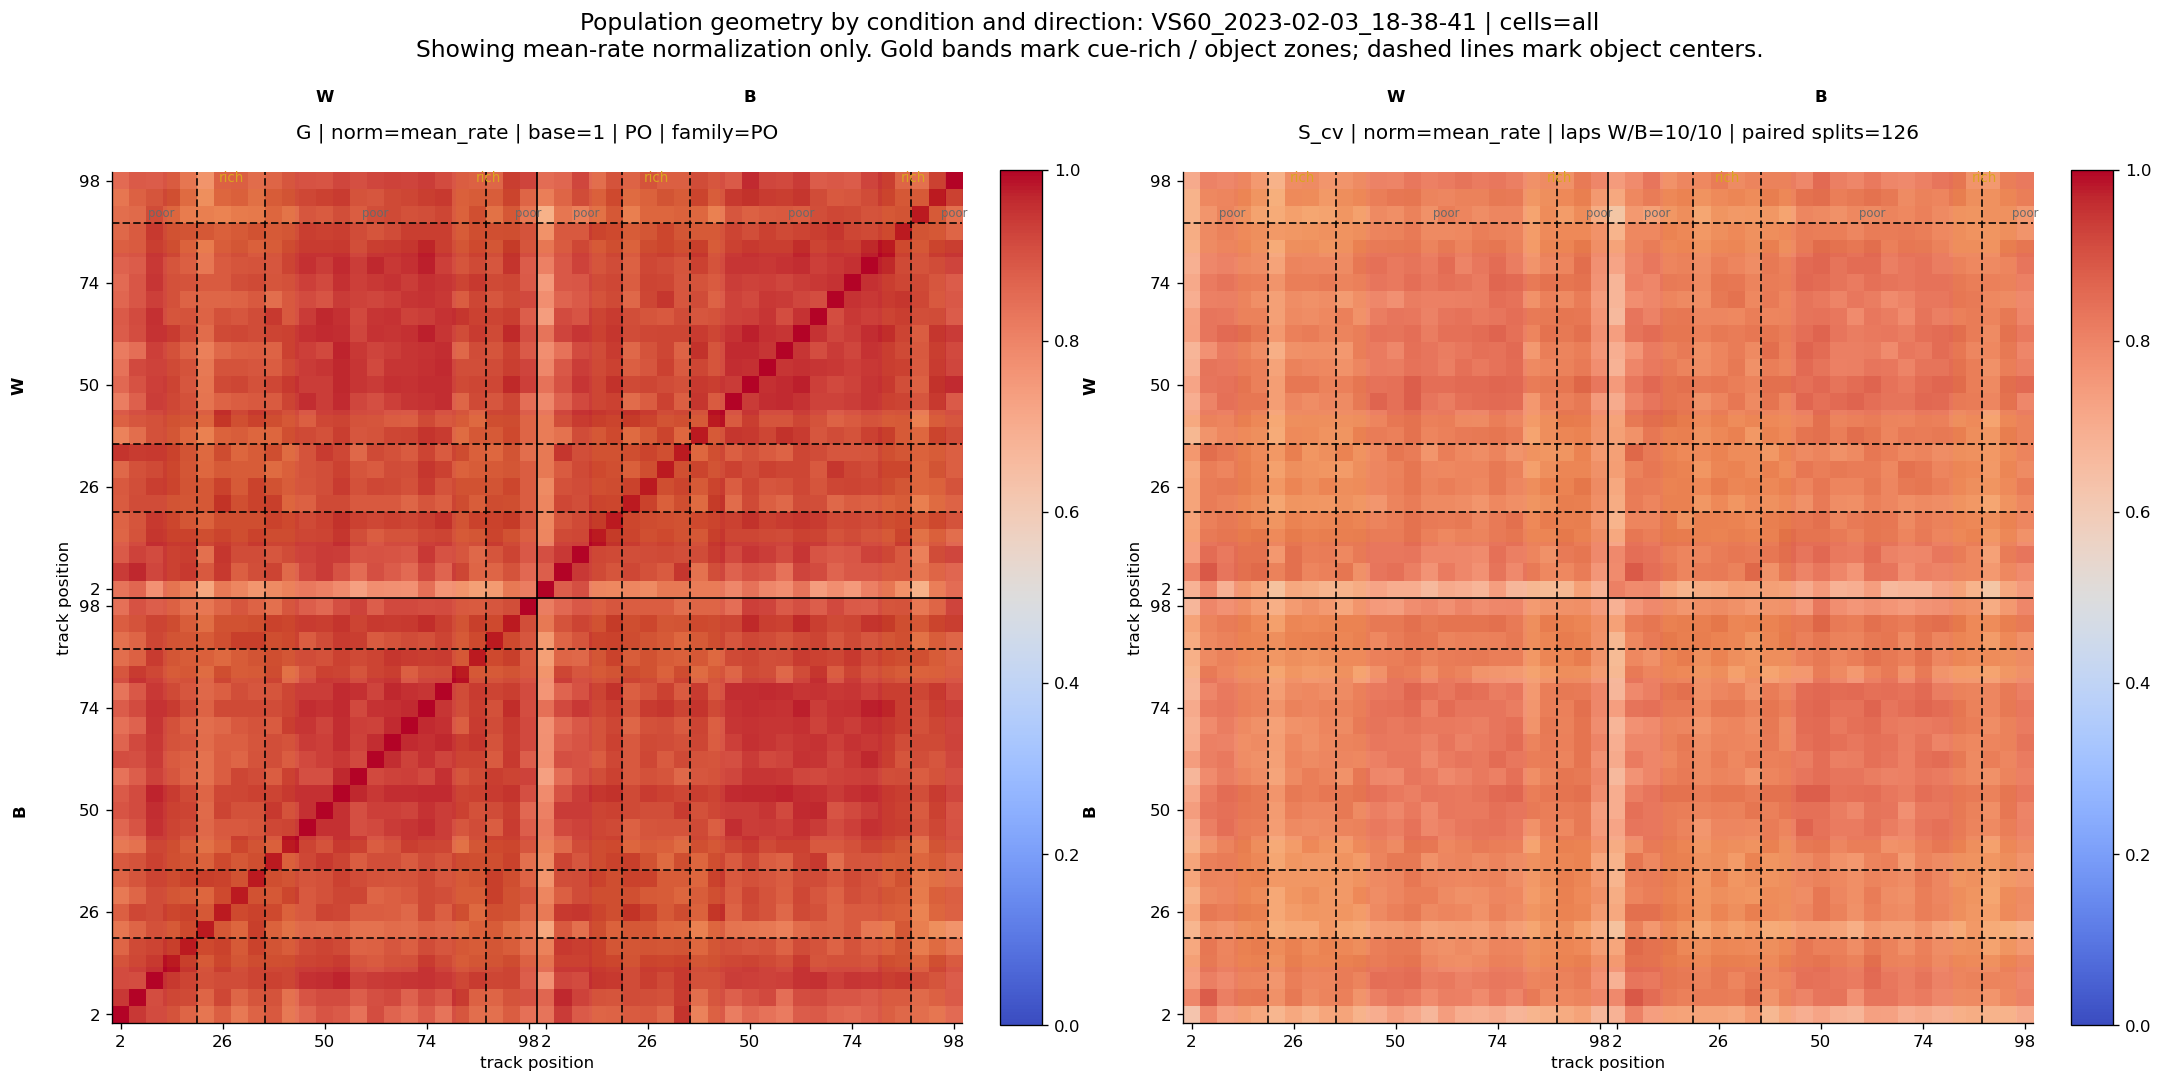

In [7]:
state = prepare_direction_plot_state(saved=saved, cfg=cfg, session_result=session_result)
edges_geom = np.asarray(state["edges_geom"], dtype=np.float64)
centers_geom = np.asarray(state["centers_geom"], dtype=np.float64)
scales_by_norm = state["scales_by_norm"]
n_geom_bins = int(state["n_geom_bins"])
norm_to_idx = dict(state["norm_to_idx"])
prepared_groups = dict(state["prepared_groups"])
direction_index_by_base = dict(state["direction_index_by_base"])

plot_norms = ["mean_rate"] if "mean_rate" in session_result.normalizations else list(session_result.normalizations)
base_conditions = sorted(direction_index_by_base)
n_rows = max(1, len(base_conditions) * len(plot_norms))

fig, axes = plt.subplots(n_rows, 2, figsize=(18, 9 * n_rows), squeeze=False)
cmap = "coolwarm"
vmin, vmax = 0.0, 1.0
empty_block = np.full((n_geom_bins, n_geom_bins), np.nan, dtype=np.float64)

for base_row, base_cond in enumerate(base_conditions):
    dir_map = direction_index_by_base[base_cond]
    g_w = dir_map.get("W")
    g_b = dir_map.get("B")
    g_ref = g_w if g_w is not None else g_b
    condition_name = str(session_result.condition_name_g[g_ref]) or f"cond_{base_cond}"
    condition_family = str(session_result.condition_family_g[g_ref]) or condition_name
    cue_layout = notebook_cue_layout_for_condition(condition_name, condition_family)
    laps_w = int(session_result.n_laps_g[g_w]) if g_w is not None else 0
    laps_b = int(session_result.n_laps_g[g_b]) if g_b is not None else 0

    for norm_row, norm in enumerate(plot_norms):
        row = base_row * len(plot_norms) + norm_row
        n_idx = norm_to_idx[str(norm)]
        ax_g = axes[row, 0]
        ax_s = axes[row, 1]

        ff_g = session_result.G_gnkk[g_w, n_idx] if g_w is not None else empty_block
        bb_g = session_result.G_gnkk[g_b, n_idx] if g_b is not None else empty_block
        ff_s = session_result.S_cv_gnkk[g_w, n_idx] if g_w is not None else empty_block
        bb_s = session_result.S_cv_gnkk[g_b, n_idx] if g_b is not None else empty_block
        wb_g = empty_block
        wb_s = empty_block
        paired_splits = 0

        if (g_w is not None) and (g_b is not None):
            condway_w = int(session_result.condway_1b_g[g_w])
            condway_b = int(session_result.condway_1b_g[g_b])
            group_w = prepared_groups[condway_w]
            group_b = prepared_groups[condway_b]
            wb_g = mean_cross_block(group_w, group_b, str(norm))
            wb_s, paired_splits = cv_cross_block(group_w, group_b, str(norm))

        combined_g = assemble_direction_block(ff_g, bb_g, wb_g)
        combined_s = assemble_direction_block(ff_s, bb_s, wb_s)

        im_g = ax_g.imshow(combined_g, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        im_s = ax_s.imshow(combined_s, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)

        ax_g.set_title(
            f"G | norm={norm} | base={base_cond} | {condition_name} | family={condition_family}",
            pad=20,
        )
        ax_s.set_title(
            f"S_cv | norm={norm} | laps W/B={laps_w}/{laps_b} | paired splits={paired_splits}",
            pad=20,
        )

        for ax in (ax_g, ax_s):
            ax.set_box_aspect(1)
            draw_cue_guides(ax, cue_layout)
            decorate_direction_axes(ax, cue_layout)
            ax.set_xlabel("track position")
            ax.set_ylabel("track position")

        fig.colorbar(im_g, ax=ax_g, fraction=0.046, pad=0.04)
        fig.colorbar(im_s, ax=ax_s, fraction=0.046, pad=0.04)

fig.suptitle(
    f"Population geometry by condition and direction: {session_id} | cells={cell_filter_label}\n"
    "Showing mean-rate normalization only. Gold bands mark cue-rich / object zones; dashed lines mark object centers.",
    y=1.01,
    fontsize=14,
)
fig.tight_layout()
plt.show()


## Cue Vs No-Cue Comparison Session

This section finds a session that contains both a cue condition family (`PO` or `POM`) and `PNO`, then plots one cue condition and one no-cue condition from the same session for direct comparison.

In [8]:
def find_session_for_no_cue_comparison(
    ratemap_root: Path,
    *,
    repo_root: Path,
    required_families: tuple[str, ...] = ("PNO",),
    cue_family_order: tuple[str, ...] = ("PO", "POM"),
    session_override: str = "",
    seed: int = 0,
    cell_classification_source: Path | None = None,
    cell_pred_types: tuple[str, ...] = (),
) -> tuple[Path, str, set[str]]:
    files = sorted(ratemap_root.rglob("*_rmap.npz"))
    if not files:
        raise FileNotFoundError(f"No *_rmap.npz files found under {ratemap_root}")

    if str(session_override).strip():
        files = [p for p in files if p.stem == f"{session_override}_rmap"]
        if not files:
            raise FileNotFoundError(
                f"Could not find comparison session {session_override!r} under {ratemap_root}"
            )
        visit_order = list(range(len(files)))
    else:
        rng = np.random.default_rng(seed)
        visit_order = rng.permutation(len(files)).tolist()

    pred_types = tuple(str(v).strip().lower() for v in cell_pred_types if str(v).strip())
    classification_table = None
    if pred_types:
        if cell_classification_source is None:
            raise ValueError("cell_classification_source is required when cell_pred_types is set")
        classification_table = load_cell_classification_table(cell_classification_source)

    needed = {canonical_condition_name(fam) for fam in required_families}
    cue_family_order_norm = tuple(canonical_condition_name(fam) for fam in cue_family_order)

    for idx in visit_order:
        path = files[idx]
        saved_candidate = load_saved_ratemap_pack(path)
        session_id = str(saved_candidate.meta.get("session_id", path.stem.removesuffix("_rmap")))
        condition_name_map = build_condition_name_map(saved_candidate, repo_root)
        if not condition_name_map:
            continue
        session_families = {
            condition_family_name(name)
            for name in condition_name_map.values()
            if condition_family_name(name)
        }
        if not needed.issubset(session_families):
            continue
        cue_family = next((fam for fam in cue_family_order_norm if fam in session_families), None)
        if cue_family is None:
            continue
        if classification_table is not None:
            selected_cell_ids = filter_cell_ids_by_pred_type(
                session_id=session_id,
                cell_ids=saved_candidate.cell_ids,
                classification_table=classification_table,
                pred_types=pred_types,
            )
            if selected_cell_ids.size == 0:
                continue
        return path, cue_family, session_families

    raise FileNotFoundError(
        "Could not find a session containing the requested no-cue comparison families "
        f"{sorted(needed)} and at least one cue family from {list(cue_family_order_norm)}."
    )


comparison_session_id: VS38_2022-10-02_18-30-08
comparison_rmap_path:  C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\results\ratemap\full\ratemap__smooth_2p8__xrem_0__minspeed_2__20260523_141633\VS38\2022-10-02\VS38_2022-10-02_18-30-08_rmap.npz
comparison_families:   ['PNO', 'PO']
cue_family:            PO
cell_filter:           all
n_cells_total:         13
n_cells_used:          13


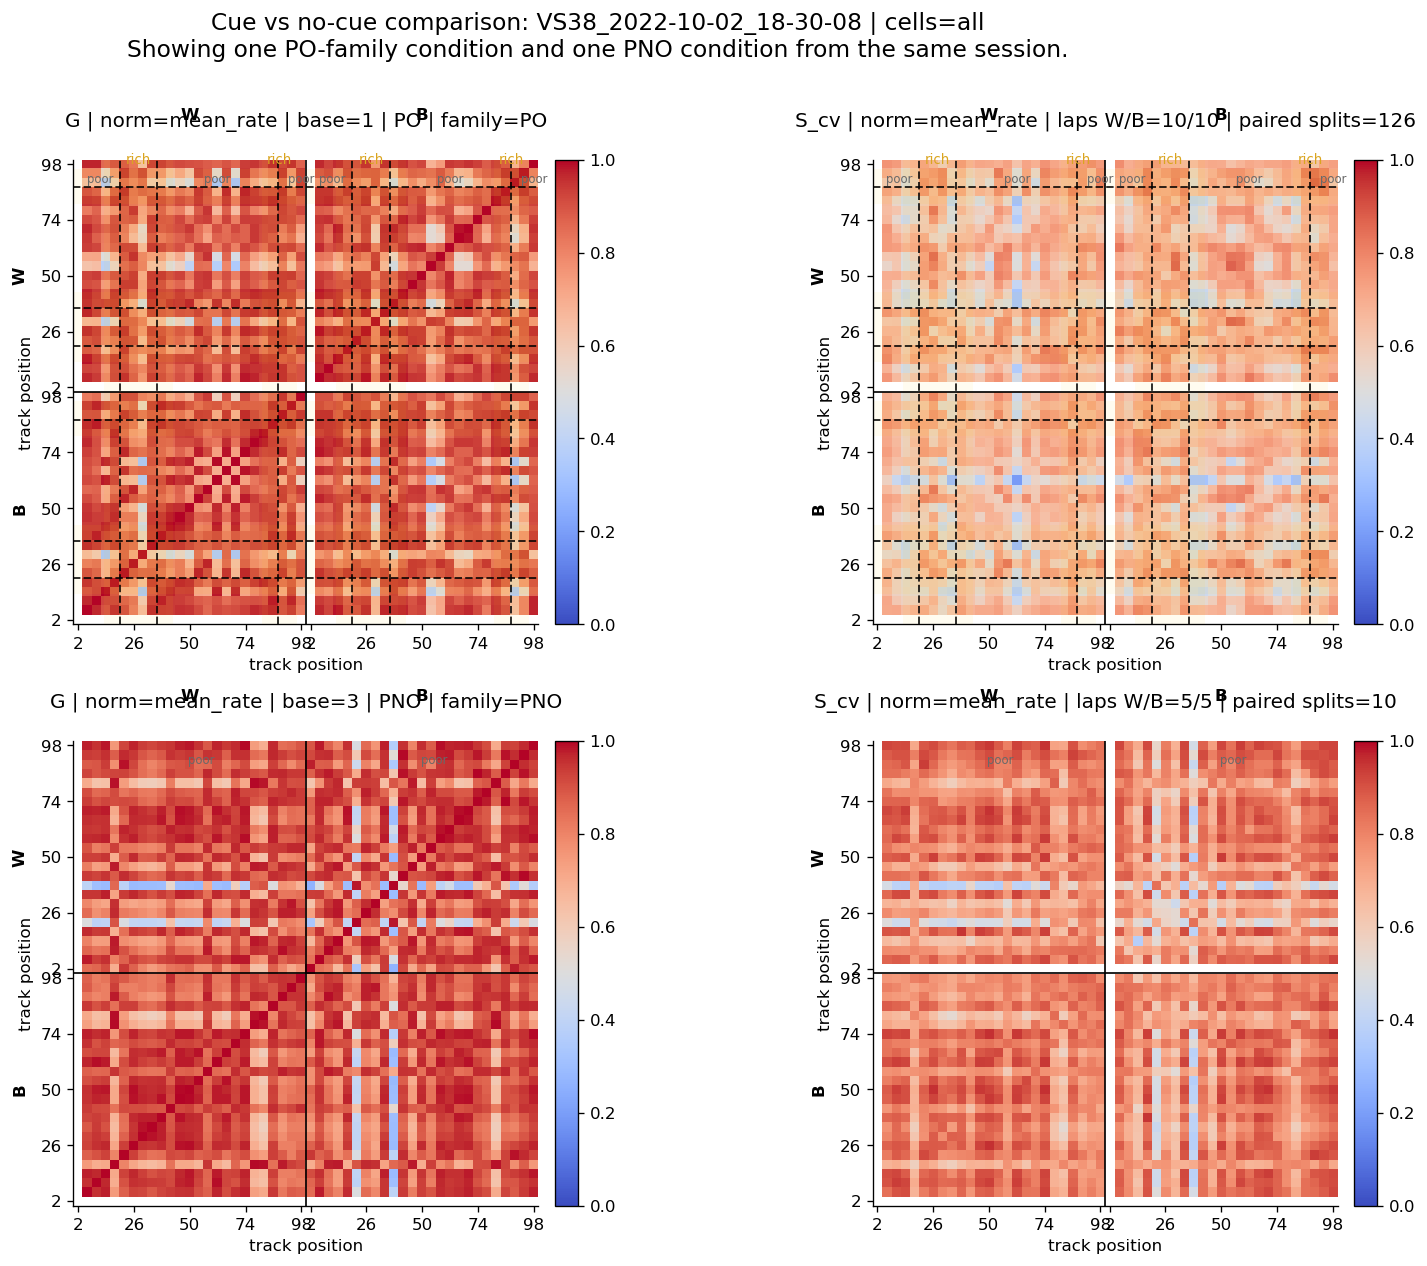

In [9]:
comparison_candidate_sessions = [
    "VS112_2025-01-10_15-36-28",
    "VS15_2022-03-02_18-18-27",
    "VS38_2022-10-02_18-30-08",
    "VS57_2022-12-18_18-51-04",
    "VS66_2023-02-20_17-36-59",
    "VS66_2023-02-21_17-55-45",
    "VS69_2023-02-24_12-16-41",
    "VS70_2023-02-24_18-36-38",
    "VS73_2023-03-21_19-53-41",
]
comparison_session_override = "VS38_2022-10-02_18-30-08"# set to "" to let the helper choose a candidate
comparison_required_families = ("PNO",)
comparison_cue_family_order = ("PO", "POM")

comparison_rmap_path, comparison_cue_family, comparison_session_families = find_session_for_no_cue_comparison(
    ratemap_root,
    repo_root=repo,
    required_families=comparison_required_families,
    cue_family_order=comparison_cue_family_order,
    session_override=comparison_session_override,
    seed=seed,
    cell_classification_source=cell_classification_source,
    cell_pred_types=cell_pred_types,
)

comparison_saved = load_saved_ratemap_pack(comparison_rmap_path)
comparison_session_id = str(
    comparison_saved.meta.get("session_id", comparison_rmap_path.stem.removesuffix("_rmap"))
)
comparison_condition_name_map = build_condition_name_map(comparison_saved, repo)

comparison_selected_pred_types = tuple(str(v).strip().lower() for v in cell_pred_types if str(v).strip())
comparison_selected_cell_ids = None
if comparison_selected_pred_types:
    comparison_classification_table = load_cell_classification_table(cell_classification_source)
    comparison_selected_cell_ids = filter_cell_ids_by_pred_type(
        session_id=comparison_session_id,
        cell_ids=comparison_saved.cell_ids,
        classification_table=comparison_classification_table,
        pred_types=comparison_selected_pred_types,
    )
    if comparison_selected_cell_ids.size == 0:
        raise ValueError(
            f"No cells matched pred_type filter {comparison_selected_pred_types!r} for comparison session {comparison_session_id}."
        )

comparison_result = build_population_geometry_from_saved_ratemap(
    saved=comparison_saved,
    cfg=cfg,
    condition_names_by_base=comparison_condition_name_map,
    selected_cell_ids=comparison_selected_cell_ids,
)

comparison_cell_filter_label = (
    ",".join(comparison_selected_pred_types) if comparison_selected_pred_types else "all"
)

print(f"comparison_session_id: {comparison_session_id}")
print(f"comparison_rmap_path:  {comparison_rmap_path}")
print(f"comparison_families:   {sorted(comparison_session_families)}")
print(f"cue_family:            {comparison_cue_family}")
print(f"cell_filter:           {comparison_cell_filter_label}")
print(f"n_cells_total:         {comparison_saved.cell_ids.size}")
print(f"n_cells_used:          {comparison_result.cell_ids_u.size}")

comparison_state = prepare_direction_plot_state(
    saved=comparison_saved,
    cfg=cfg,
    session_result=comparison_result,
)
edges_geom = np.asarray(comparison_state["edges_geom"], dtype=np.float64)
centers_geom = np.asarray(comparison_state["centers_geom"], dtype=np.float64)
scales_by_norm = comparison_state["scales_by_norm"]
n_geom_bins = int(comparison_state["n_geom_bins"])
norm_to_idx = dict(comparison_state["norm_to_idx"])
prepared_groups = dict(comparison_state["prepared_groups"])
direction_index_by_base = dict(comparison_state["direction_index_by_base"])

family_to_base: dict[str, int] = {}
for base_cond in sorted(direction_index_by_base):
    dir_map = direction_index_by_base[base_cond]
    g_ref = dir_map.get("W")
    if g_ref is None:
        g_ref = dir_map.get("B")
    if g_ref is None:
        continue
    family = str(comparison_result.condition_family_g[g_ref])
    family_to_base.setdefault(family, base_cond)

comparison_base_conditions: list[int] = []
if comparison_cue_family in family_to_base:
    comparison_base_conditions.append(family_to_base[comparison_cue_family])
if "PNO" in family_to_base:
    comparison_base_conditions.append(family_to_base["PNO"])
if len(comparison_base_conditions) < 2:
    raise ValueError(
        f"Expected one cue condition and one PNO condition in comparison session {comparison_session_id}."
    )

plot_norms = ["mean_rate"] if "mean_rate" in comparison_result.normalizations else list(comparison_result.normalizations)
n_rows = max(1, len(comparison_base_conditions) * len(plot_norms))

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5.2 * n_rows), squeeze=False)
cmap = "coolwarm"
vmin, vmax = 0.0, 1.0
empty_block = np.full((n_geom_bins, n_geom_bins), np.nan, dtype=np.float64)

for base_row, base_cond in enumerate(comparison_base_conditions):
    dir_map = direction_index_by_base[base_cond]
    g_w = dir_map.get("W")
    g_b = dir_map.get("B")
    g_ref = g_w if g_w is not None else g_b
    condition_name = str(comparison_result.condition_name_g[g_ref]) or f"cond_{base_cond}"
    condition_family = str(comparison_result.condition_family_g[g_ref]) or condition_name
    cue_layout = notebook_cue_layout_for_condition(condition_name, condition_family)
    laps_w = int(comparison_result.n_laps_g[g_w]) if g_w is not None else 0
    laps_b = int(comparison_result.n_laps_g[g_b]) if g_b is not None else 0

    for norm_row, norm in enumerate(plot_norms):
        row = base_row * len(plot_norms) + norm_row
        n_idx = norm_to_idx[str(norm)]
        ax_g = axes[row, 0]
        ax_s = axes[row, 1]

        ff_g = comparison_result.G_gnkk[g_w, n_idx] if g_w is not None else empty_block
        bb_g = comparison_result.G_gnkk[g_b, n_idx] if g_b is not None else empty_block
        ff_s = comparison_result.S_cv_gnkk[g_w, n_idx] if g_w is not None else empty_block
        bb_s = comparison_result.S_cv_gnkk[g_b, n_idx] if g_b is not None else empty_block
        wb_g = empty_block
        wb_s = empty_block
        paired_splits = 0

        if (g_w is not None) and (g_b is not None):
            condway_w = int(comparison_result.condway_1b_g[g_w])
            condway_b = int(comparison_result.condway_1b_g[g_b])
            group_w = prepared_groups[condway_w]
            group_b = prepared_groups[condway_b]
            wb_g = mean_cross_block(group_w, group_b, str(norm))
            wb_s, paired_splits = cv_cross_block(group_w, group_b, str(norm))

        combined_g = assemble_direction_block(ff_g, bb_g, wb_g)
        combined_s = assemble_direction_block(ff_s, bb_s, wb_s)

        im_g = ax_g.imshow(combined_g, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        im_s = ax_s.imshow(combined_s, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)

        ax_g.set_title(
            f"G | norm={norm} | base={base_cond} | {condition_name} | family={condition_family}",
            pad=20,
        )
        ax_s.set_title(
            f"S_cv | norm={norm} | laps W/B={laps_w}/{laps_b} | paired splits={paired_splits}",
            pad=20,
        )

        for ax in (ax_g, ax_s):
            ax.set_box_aspect(1)
            draw_cue_guides(ax, cue_layout)
            decorate_direction_axes(ax, cue_layout)
            ax.set_xlabel("track position")
            ax.set_ylabel("track position")

        fig.colorbar(im_g, ax=ax_g, fraction=0.035, pad=0.02)
        fig.colorbar(im_s, ax=ax_s, fraction=0.035, pad=0.02)

fig.suptitle(
    f"Cue vs no-cue comparison: {comparison_session_id} | cells={comparison_cell_filter_label}\n"
    f"Showing one {comparison_cue_family}-family condition and one PNO condition from the same session.",
    y=1.01,
    fontsize=14,
)
fig.tight_layout()
plt.show()


## G Displacement Profiles

This section summarizes the mean geometry matrix `G(x, x')` with positive-lag profiles:

- `g_all(Δx)`
- `g_rich(Δx)` and `g_poor(Δx)` using anchor-bin zone labels
- `g_rich_within(Δx)` and `g_poor_within(Δx)` requiring both bins to stay inside the zone

For `PNO`, the rich/poor windows are defined using the matched cue-family layout so the comparison stays spatially homologous.

In [10]:
from placefields import DisplacementProfile, ZoneDisplacementProfiles


def merge_displacement_profiles(profiles: list[DisplacementProfile]) -> DisplacementProfile:
    if not profiles:
        raise ValueError("profiles must contain at least one DisplacementProfile")
    delta_bin = np.asarray(profiles[0].delta_bin, dtype=np.int64)
    delta_x = np.asarray(profiles[0].delta_x, dtype=np.float64)
    n_lag = int(delta_bin.size)
    total_pairs = np.zeros(n_lag, dtype=np.int64)
    weighted_sum = np.zeros(n_lag, dtype=np.float64)
    for profile in profiles:
        if not np.array_equal(delta_bin, np.asarray(profile.delta_bin, dtype=np.int64)):
            raise ValueError("All profiles must use the same delta_bin grid")
        count = np.asarray(profile.n_pairs, dtype=np.int64)
        mean = np.asarray(profile.mean, dtype=np.float64)
        valid = (count > 0) & np.isfinite(mean)
        total_pairs[valid] += count[valid]
        weighted_sum[valid] += mean[valid] * count[valid]
    merged_mean = np.full(n_lag, np.nan, dtype=np.float64)
    use = total_pairs > 0
    merged_mean[use] = weighted_sum[use] / total_pairs[use]
    return DisplacementProfile(
        delta_bin=delta_bin,
        delta_x=delta_x,
        mean=merged_mean,
        n_pairs=total_pairs,
    )


def merge_zone_displacement_profiles(profiles: list[ZoneDisplacementProfiles]) -> ZoneDisplacementProfiles:
    if not profiles:
        raise ValueError("profiles must contain at least one ZoneDisplacementProfiles")
    merged_all = merge_displacement_profiles([profile.all_profile for profile in profiles])
    zone_names = list(profiles[0].anchor_profiles)
    merged_anchor = {
        zone_name: merge_displacement_profiles(
            [profile.anchor_profiles[zone_name] for profile in profiles]
        )
        for zone_name in zone_names
    }
    merged_within = {
        zone_name: merge_displacement_profiles(
            [profile.within_profiles[zone_name] for profile in profiles]
        )
        for zone_name in zone_names
    }
    return ZoneDisplacementProfiles(
        zone_labels_k=np.asarray(profiles[0].zone_labels_k, dtype=np.str_),
        all_profile=merged_all,
        anchor_profiles=merged_anchor,
        within_profiles=merged_within,
        layout=profiles[0].layout,
    )


def build_direction_pooled_G_profiles(
    result,
    *,
    base_condition_1b: int,
    normalization: str,
    homologous_layout=None,
) -> tuple[ZoneDisplacementProfiles, list[str]]:
    norm_to_idx = {str(norm): i for i, norm in enumerate(result.normalizations)}
    if normalization not in norm_to_idx:
        raise KeyError(f"Normalization {normalization!r} not present in result")
    n_idx = int(norm_to_idx[normalization])
    profiles_by_direction: list[ZoneDisplacementProfiles] = []
    directions_used: list[str] = []
    for g_idx in range(int(result.condway_1b_g.size)):
        if int(result.base_condition_1b_g[g_idx]) != int(base_condition_1b):
            continue
        directions_used.append(str(result.direction_g[g_idx]))
        matrix = np.asarray(result.G_gnkk[g_idx, n_idx], dtype=np.float64)
        valid = np.asarray(result.valid_mean_gnk[g_idx, n_idx], dtype=bool)
        if homologous_layout is None:
            profiles = compute_condition_zone_displacement_profiles(
                matrix,
                xbin_centers=result.xbin_centers,
                valid_mask_k=valid,
                condition_name=str(result.condition_name_g[g_idx]),
                condition_family=str(result.condition_family_g[g_idx]),
            )
        else:
            zone_labels = label_xbin_centers_by_zone(
                result.xbin_centers,
                layout=homologous_layout,
            )
            profiles = compute_zone_displacement_profiles(
                matrix,
                zone_labels_k=zone_labels,
                xbin_centers=result.xbin_centers,
                valid_mask_k=valid,
                layout=homologous_layout,
            )
        profiles_by_direction.append(profiles)
    if not profiles_by_direction:
        raise ValueError(f"No groups found for base_condition_1b={base_condition_1b}")
    return merge_zone_displacement_profiles(profiles_by_direction), directions_used


def build_direction_pooled_G_component_profiles(
    result,
    *,
    base_condition_1b: int,
    normalization: str,
    homologous_layout=None,
    include_rich: bool = True,
    include_poor: bool = True,
) -> tuple[ZoneDisplacementProfiles, list[str]]:
    if not include_rich and not include_poor:
        raise ValueError("At least one of include_rich or include_poor must be True")
    norm_to_idx = {str(norm): i for i, norm in enumerate(result.normalizations)}
    if normalization not in norm_to_idx:
        raise KeyError(f"Normalization {normalization!r} not present in result")
    n_idx = int(norm_to_idx[normalization])
    profiles_by_direction: list[ZoneDisplacementProfiles] = []
    directions_used: list[str] = []
    for g_idx in range(int(result.condway_1b_g.size)):
        if int(result.base_condition_1b_g[g_idx]) != int(base_condition_1b):
            continue
        directions_used.append(str(result.direction_g[g_idx]))
        matrix = np.asarray(result.G_gnkk[g_idx, n_idx], dtype=np.float64)
        valid = np.asarray(result.valid_mean_gnk[g_idx, n_idx], dtype=bool)
        if homologous_layout is None:
            profiles = compute_condition_component_displacement_profiles(
                matrix,
                xbin_centers=result.xbin_centers,
                valid_mask_k=valid,
                condition_name=str(result.condition_name_g[g_idx]),
                condition_family=str(result.condition_family_g[g_idx]),
                include_rich=include_rich,
                include_poor=include_poor,
            )
        else:
            zone_labels = label_xbin_centers_by_zone_component(
                result.xbin_centers,
                layout=homologous_layout,
            )
            zone_names = zone_component_names_for_layout(
                homologous_layout,
                include_rich=include_rich,
                include_poor=include_poor,
            )
            profiles = compute_zone_displacement_profiles(
                matrix,
                zone_labels_k=zone_labels,
                xbin_centers=result.xbin_centers,
                valid_mask_k=valid,
                zone_names=zone_names,
                layout=homologous_layout,
            )
        profiles_by_direction.append(profiles)
    if not profiles_by_direction:
        raise ValueError(f"No groups found for base_condition_1b={base_condition_1b}")
    return merge_zone_displacement_profiles(profiles_by_direction), directions_used


PROFILE_SPECS = [
    ("all_profile", None, "all", "black", "-"),
    ("anchor_profiles", "rich", "rich anchor", "tab:orange", "-"),
    ("anchor_profiles", "poor", "poor anchor", "tab:blue", "-"),
    ("within_profiles", "rich", "rich within", "tab:orange", "--"),
    ("within_profiles", "poor", "poor within", "tab:blue", "--"),
]


def _get_profile(bundle: ZoneDisplacementProfiles, family_key: str, zone_key: str | None):
    if family_key == "all_profile":
        return bundle.all_profile
    return getattr(bundle, family_key)[str(zone_key)]


def plot_G_profile_bundle(ax_curve, ax_pairs, bundle: ZoneDisplacementProfiles, *, title: str) -> None:
    for family_key, zone_key, label, color, linestyle in PROFILE_SPECS:
        profile = _get_profile(bundle, family_key, zone_key)
        x = np.asarray(profile.delta_x, dtype=np.float64)
        y = np.asarray(profile.mean, dtype=np.float64)
        n = np.asarray(profile.n_pairs, dtype=np.int64)
        use_curve = (n > 0) & np.isfinite(x) & np.isfinite(y)
        use_pairs = (n > 0) & np.isfinite(x)
        if np.any(use_curve):
            ax_curve.plot(x[use_curve], y[use_curve], label=label, color=color, ls=linestyle, lw=2)
        if np.any(use_pairs):
            ax_pairs.plot(x[use_pairs], n[use_pairs], label=label, color=color, ls=linestyle, lw=1.8)
    ax_curve.set_title(title)
    ax_curve.set_ylabel("mean G")
    ax_curve.set_ylim(0.0, 1.02)
    ax_curve.grid(True, alpha=0.25)
    ax_curve.legend(loc="best", ncol=2, fontsize=9)
    ax_pairs.set_ylabel("n pairs")
    ax_pairs.set_xlabel("Δx (track units)")
    ax_pairs.grid(True, alpha=0.25)


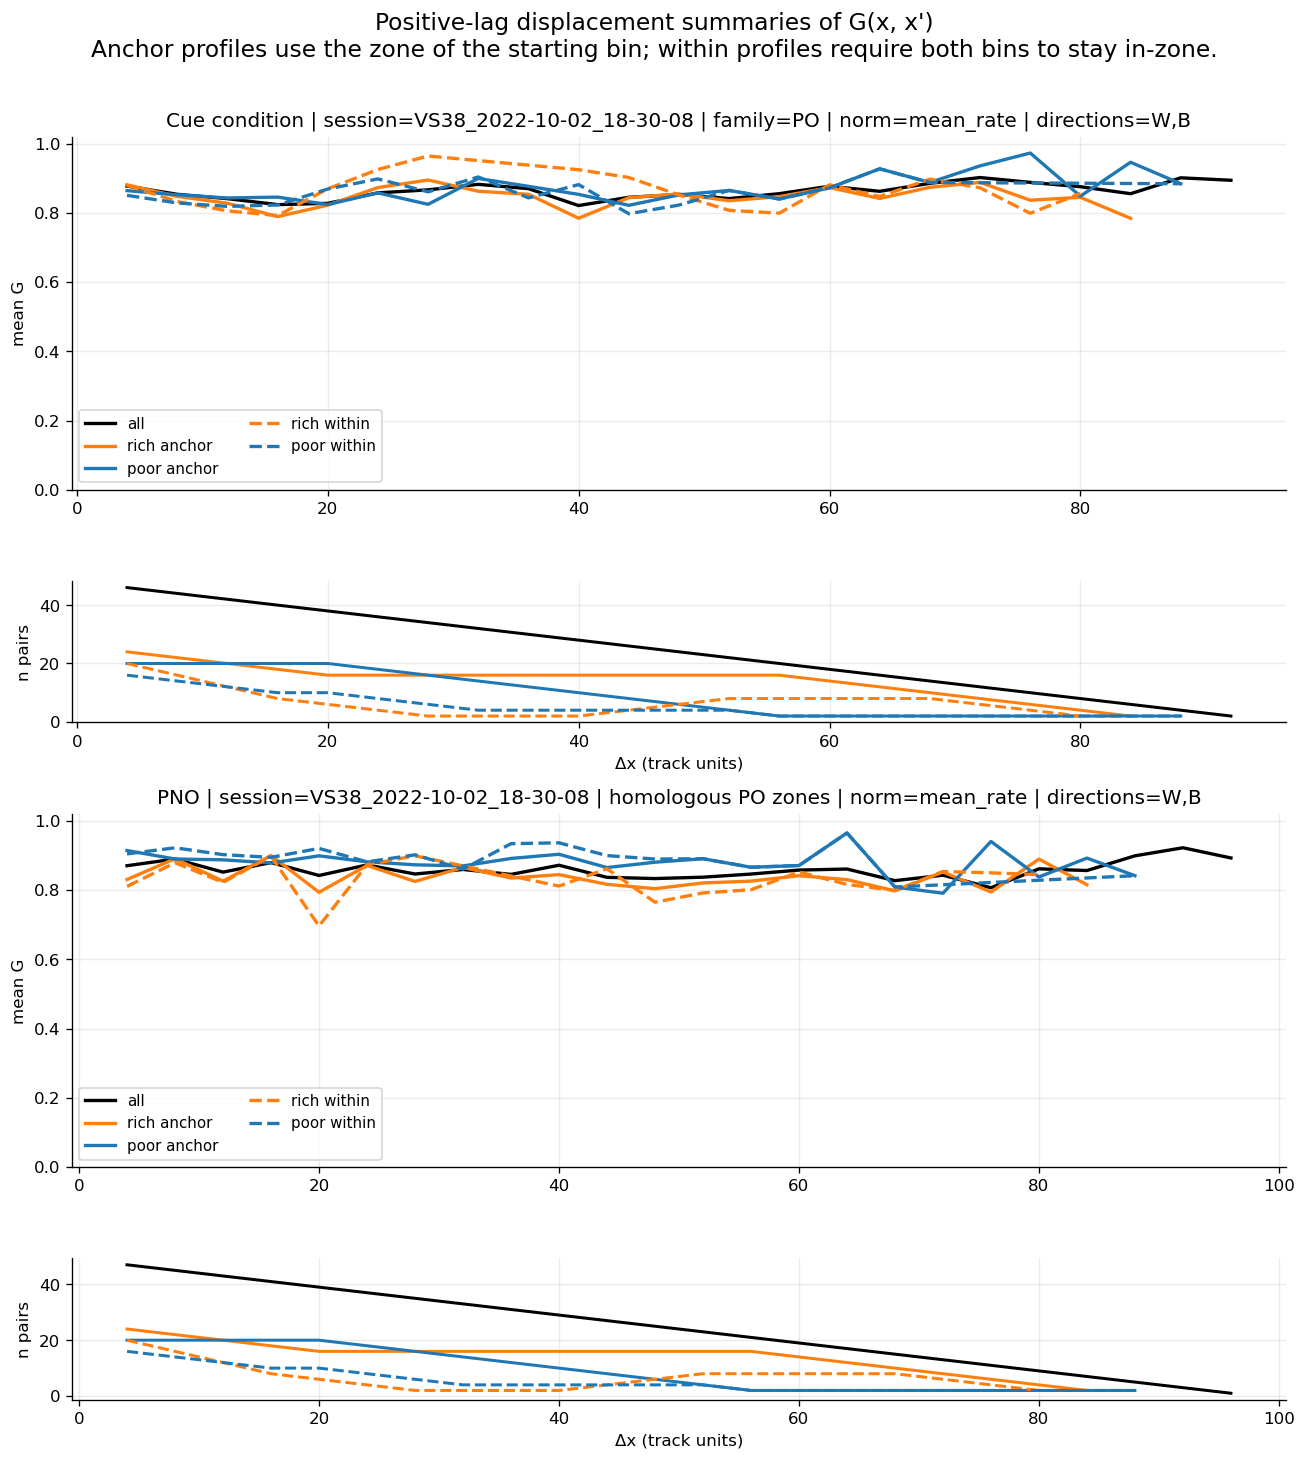

In [11]:
profile_norm = "mean_rate" if "mean_rate" in comparison_result.normalizations else str(comparison_result.normalizations[0])
cue_base_condition = int(family_to_base[comparison_cue_family])
pno_base_condition = int(family_to_base["PNO"])
homologous_cue_layout = cue_zone_layout_for_condition(condition_family=comparison_cue_family)

cue_profiles, cue_directions = build_direction_pooled_G_profiles(
    comparison_result,
    base_condition_1b=cue_base_condition,
    normalization=profile_norm,
)
pno_profiles, pno_directions = build_direction_pooled_G_profiles(
    comparison_result,
    base_condition_1b=pno_base_condition,
    normalization=profile_norm,
    homologous_layout=homologous_cue_layout,
)

fig, axes = plt.subplots(
    4,
    1,
    figsize=(11, 12),
    sharex=False,
    gridspec_kw={"height_ratios": [3.0, 1.2, 3.0, 1.2]},
)

plot_G_profile_bundle(
    axes[0],
    axes[1],
    cue_profiles,
    title=(
        f"Cue condition | session={comparison_session_id} | family={comparison_cue_family} "
        f"| norm={profile_norm} | directions={','.join(cue_directions)}"
    ),
)
plot_G_profile_bundle(
    axes[2],
    axes[3],
    pno_profiles,
    title=(
        f"PNO | session={comparison_session_id} | homologous {comparison_cue_family} zones "
        f"| norm={profile_norm} | directions={','.join(pno_directions)}"
    ),
)

fig.suptitle(
    "Positive-lag displacement summaries of G(x, x')\n"
    "Anchor profiles use the zone of the starting bin; within profiles require both bins to stay in-zone.",
    y=1.01,
    fontsize=14,
)
fig.tight_layout()
plt.show()


## Mirrored Within-Zone Comparison

This view keeps only the within-zone geometry summaries `g(|Delta x|)^within` and compares the cue condition against `PNO` on the same homologous `PO` rich/poor windows. The positive-lag profile is mirrored for visualization so the curve is shown on both negative and positive lags.

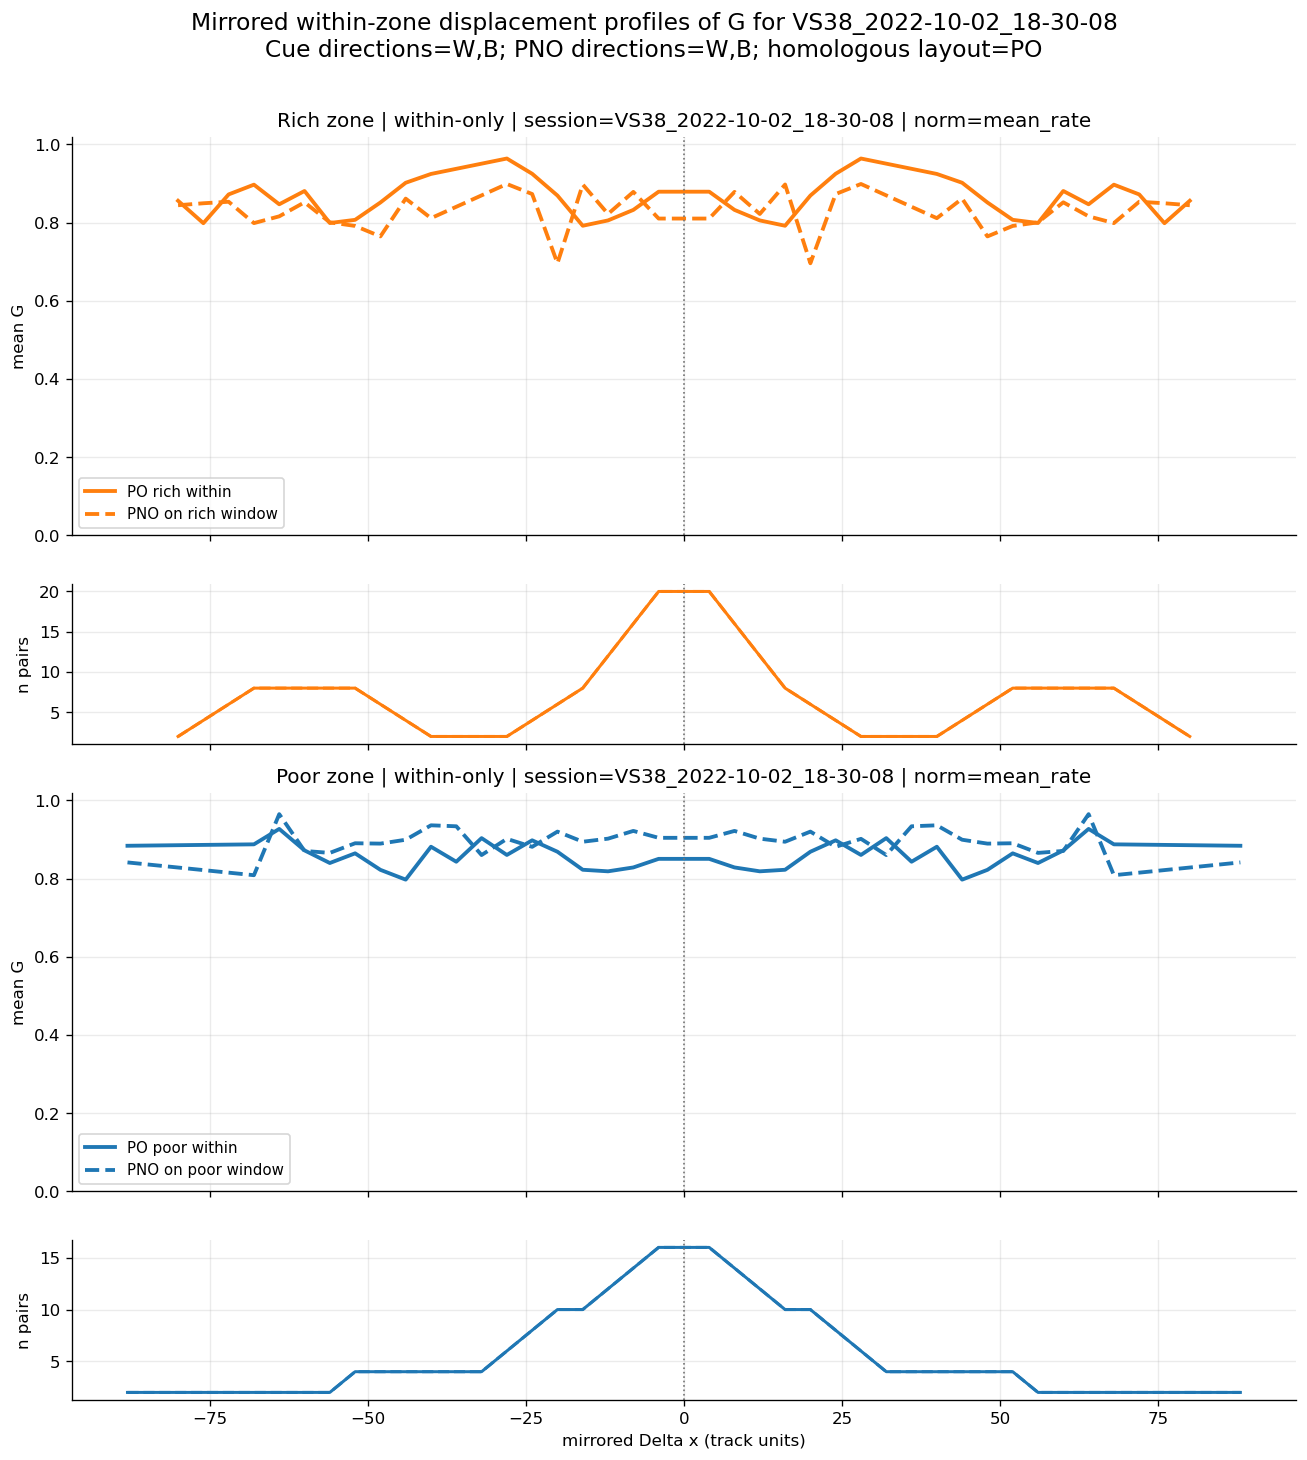

In [12]:
cue_profiles_same_zones, cue_directions_same_zones = build_direction_pooled_G_profiles(
    comparison_result,
    base_condition_1b=cue_base_condition,
    normalization=profile_norm,
    homologous_layout=homologous_cue_layout,
)
pno_profiles_same_zones, pno_directions_same_zones = build_direction_pooled_G_profiles(
    comparison_result,
    base_condition_1b=pno_base_condition,
    normalization=profile_norm,
    homologous_layout=homologous_cue_layout,
)


def mirrored_profile_arrays(profile: DisplacementProfile) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = np.asarray(profile.delta_x, dtype=np.float64)
    y = np.asarray(profile.mean, dtype=np.float64)
    n = np.asarray(profile.n_pairs, dtype=np.int64)
    use = (n > 0) & np.isfinite(x) & np.isfinite(y)
    x_use = x[use]
    y_use = y[use]
    n_use = n[use]
    if x_use.size == 0:
        return x_use, y_use, n_use
    x_mirror = np.concatenate([-x_use[::-1], x_use])
    y_mirror = np.concatenate([y_use[::-1], y_use])
    n_mirror = np.concatenate([n_use[::-1], n_use])
    return x_mirror, y_mirror, n_mirror


WITHIN_ZONE_STYLES = {
    "rich": {
        "cue_label": f"{comparison_cue_family} rich within",
        "pno_label": "PNO on rich window",
        "color": "tab:orange",
    },
    "poor": {
        "cue_label": f"{comparison_cue_family} poor within",
        "pno_label": "PNO on poor window",
        "color": "tab:blue",
    },
}

fig, axes = plt.subplots(
    4,
    1,
    figsize=(11, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.2, 3.0, 1.2]},
)

for row_idx, zone_name in enumerate(("rich", "poor")):
    ax_curve = axes[2 * row_idx]
    ax_pairs = axes[2 * row_idx + 1]
    style = WITHIN_ZONE_STYLES[zone_name]

    cue_profile = cue_profiles_same_zones.within_profiles[zone_name]
    pno_profile = pno_profiles_same_zones.within_profiles[zone_name]

    cue_x, cue_y, cue_n = mirrored_profile_arrays(cue_profile)
    pno_x, pno_y, pno_n = mirrored_profile_arrays(pno_profile)

    if cue_x.size:
        ax_curve.plot(cue_x, cue_y, color=style["color"], lw=2.3, ls="-", label=style["cue_label"])
        ax_pairs.plot(cue_x, cue_n, color=style["color"], lw=1.8, ls="-")
    if pno_x.size:
        ax_curve.plot(pno_x, pno_y, color=style["color"], lw=2.3, ls="--", label=style["pno_label"])
        ax_pairs.plot(pno_x, pno_n, color=style["color"], lw=1.8, ls="--")

    ax_curve.axvline(0.0, color="0.45", lw=1.0, ls=":")
    ax_pairs.axvline(0.0, color="0.45", lw=1.0, ls=":")
    ax_curve.set_title(
        f"{zone_name.capitalize()} zone | within-only | session={comparison_session_id} | norm={profile_norm}"
    )
    ax_curve.set_ylabel("mean G")
    ax_curve.set_ylim(0.0, 1.02)
    ax_curve.grid(True, alpha=0.25)
    ax_curve.legend(loc="best", fontsize=9)
    ax_pairs.set_ylabel("n pairs")
    ax_pairs.grid(True, alpha=0.25)

axes[-1].set_xlabel("mirrored Delta x (track units)")
fig.suptitle(
    f"Mirrored within-zone displacement profiles of G for {comparison_session_id}\n"
    f"Cue directions={','.join(cue_directions_same_zones)}; PNO directions={','.join(pno_directions_same_zones)}; homologous layout={comparison_cue_family}",
    y=1.01,
    fontsize=14,
)
fig.tight_layout()
plt.show()


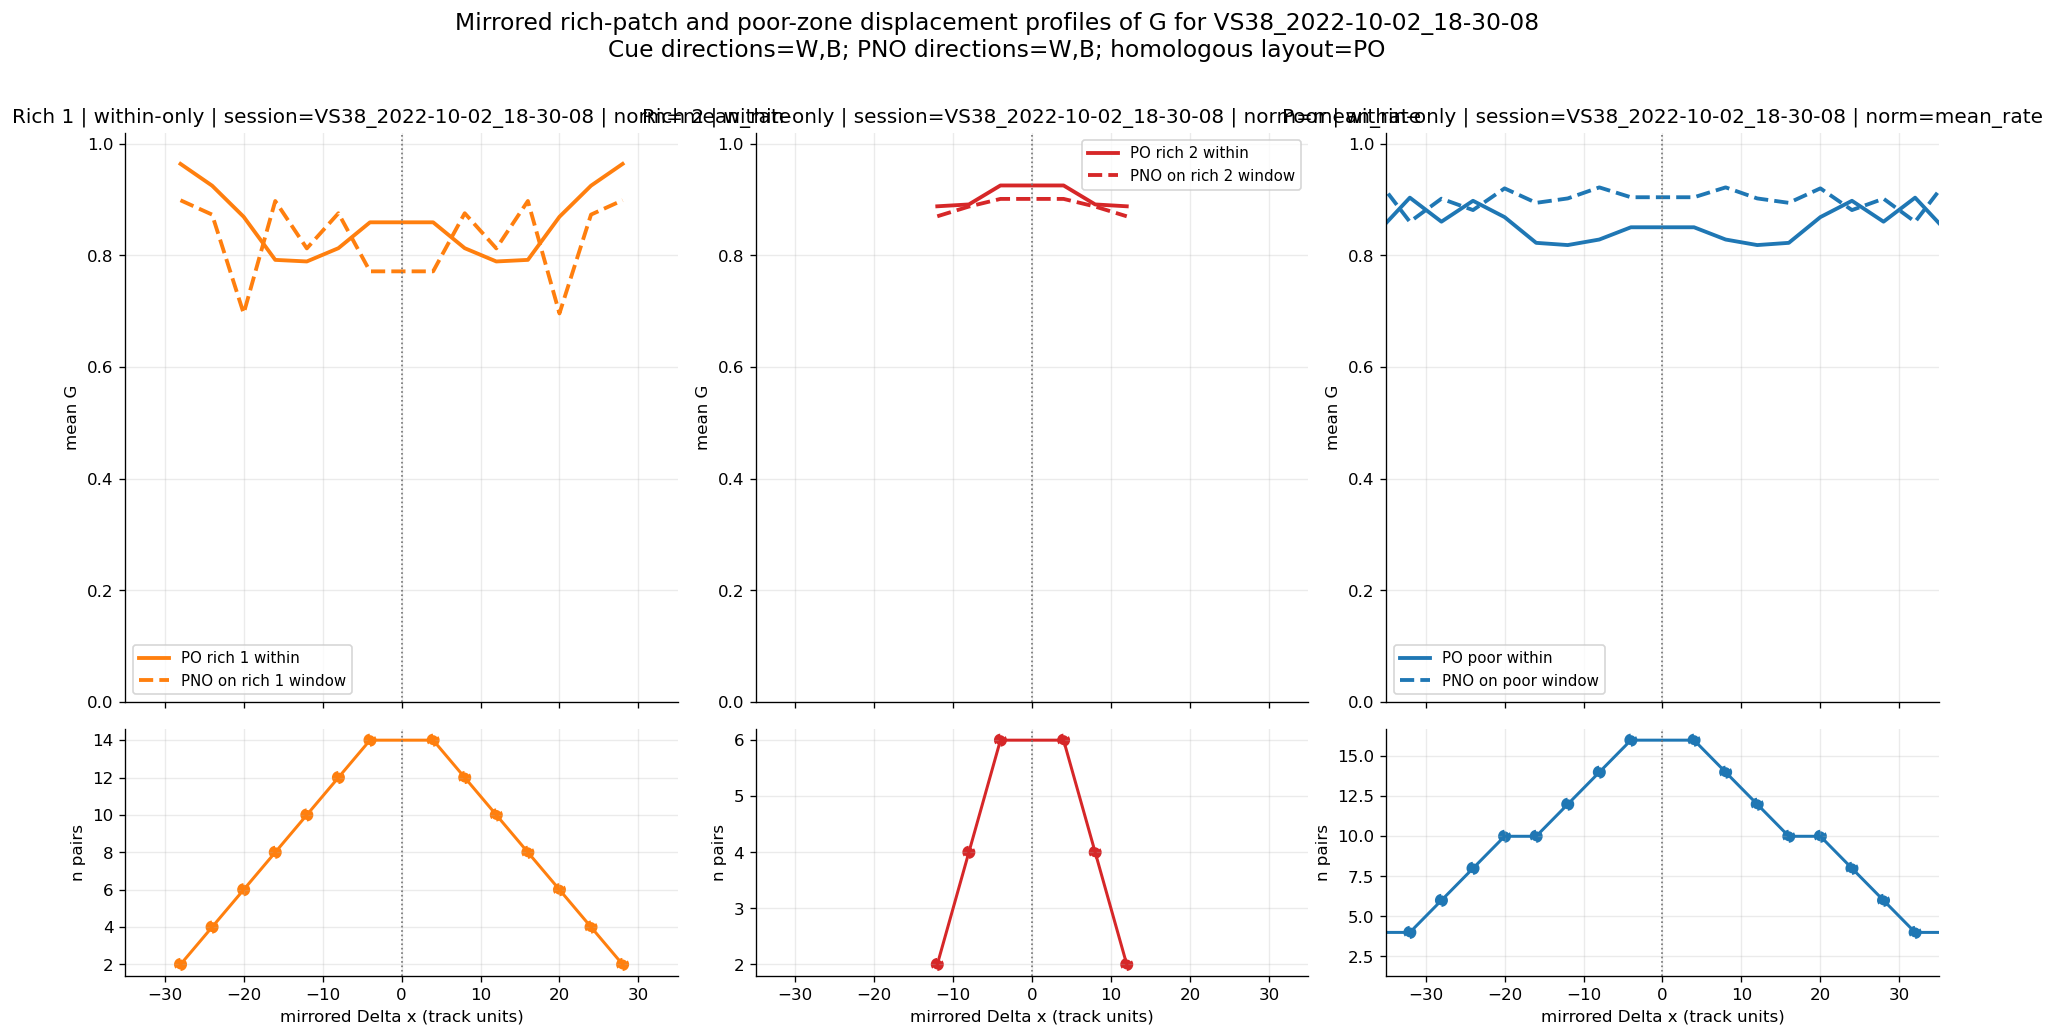

In [13]:
cue_component_profiles, cue_component_directions = build_direction_pooled_G_component_profiles(
    comparison_result,
    base_condition_1b=cue_base_condition,
    normalization=profile_norm,
    homologous_layout=homologous_cue_layout,
    include_rich=True,
    include_poor=False,
)
pno_component_profiles, pno_component_directions = build_direction_pooled_G_component_profiles(
    comparison_result,
    base_condition_1b=pno_base_condition,
    normalization=profile_norm,
    homologous_layout=homologous_cue_layout,
    include_rich=True,
    include_poor=False,
)
cue_poor_profiles, cue_poor_directions = build_direction_pooled_G_profiles(
    comparison_result,
    base_condition_1b=cue_base_condition,
    normalization=profile_norm,
    homologous_layout=homologous_cue_layout,
)
pno_poor_profiles, pno_poor_directions = build_direction_pooled_G_profiles(
    comparison_result,
    base_condition_1b=pno_base_condition,
    normalization=profile_norm,
    homologous_layout=homologous_cue_layout,
)

ZONE_PANEL_SPECS = {
    "rich_1": {
        "cue_label": f"{comparison_cue_family} rich 1 within",
        "pno_label": "PNO on rich 1 window",
        "color": "tab:orange",
        "cue_bundle": cue_component_profiles,
        "pno_bundle": pno_component_profiles,
        "zone_key": "rich_1",
    },
    "rich_2": {
        "cue_label": f"{comparison_cue_family} rich 2 within",
        "pno_label": "PNO on rich 2 window",
        "color": "tab:red",
        "cue_bundle": cue_component_profiles,
        "pno_bundle": pno_component_profiles,
        "zone_key": "rich_2",
    },
    "poor": {
        "cue_label": f"{comparison_cue_family} poor within",
        "pno_label": "PNO on poor window",
        "color": "tab:blue",
        "cue_bundle": cue_poor_profiles,
        "pno_bundle": pno_poor_profiles,
        "zone_key": "poor",
    },
}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.3]},
)

for col_idx, zone_name in enumerate(("rich_1", "rich_2", "poor")):
    ax_curve = axes[0, col_idx]
    ax_pairs = axes[1, col_idx]
    style = ZONE_PANEL_SPECS[zone_name]

    cue_profile = style["cue_bundle"].within_profiles[style["zone_key"]]
    pno_profile = style["pno_bundle"].within_profiles[style["zone_key"]]

    cue_x, cue_y, cue_n = mirrored_profile_arrays(cue_profile)
    pno_x, pno_y, pno_n = mirrored_profile_arrays(pno_profile)

    if cue_x.size:
        ax_curve.plot(cue_x, cue_y, color=style["color"], lw=2.3, ls="-", label=style["cue_label"])
        ax_pairs.plot(cue_x, cue_n, color=style["color"], lw=1.8, ls="-")
    if pno_x.size:
        ax_curve.plot(pno_x, pno_y, color=style["color"], lw=2.3, ls="--", label=style["pno_label"])
        ax_pairs.scatter(pno_x, pno_n, color=style["color"], lw=1.8, ls="--")

    ax_curve.axvline(0.0, color="0.45", lw=1.0, ls=":")
    ax_pairs.axvline(0.0, color="0.45", lw=1.0, ls=":")
    ax_curve.set_title(
        f"{zone_name.replace('_', ' ').title()} | within-only | session={comparison_session_id} | norm={profile_norm}"
    )
    ax_curve.set_ylabel("mean G")
    ax_curve.set_ylim(0.0, 1.02)
    ax_curve.grid(True, alpha=0.25)
    ax_curve.legend(loc="best", fontsize=9)
    ax_pairs.set_ylabel("n pairs")
    ax_pairs.grid(True, alpha=0.25)

for ax in axes[1, :]:
    ax.set_xlabel("mirrored Delta x (track units)")
fig.suptitle(
    f"Mirrored rich-patch and poor-zone displacement profiles of G for {comparison_session_id}\n"
    f"Cue directions={','.join(cue_component_directions)}; PNO directions={','.join(pno_component_directions)}; homologous layout={comparison_cue_family}",
    y=1.01,
    fontsize=14,
)
for ax in axes.ravel():
    ax.set_xlim(-35, 35)
fig.tight_layout()
plt.show()
